# Vignette Embedding Analysis
Loads **all 500 personas** x 10 models x 3 conditions (up to 15 000 vignettes),
computes sentence embeddings, selects UMAP `n_neighbors` by maximising
trustworthiness + continuity, projects to 2-D, and computes semantic diversity metrics.

**All heavy computations are cached to disk** in `data/analysis/`.
Delete the relevant file to recompute:
| File | Content |
|---|---|
| `all_vignettes.parquet` | vignette dataframe |
| `embeddings_minilm.npy` | sentence embeddings |
| `neighbor_selection.json` | T & C scores per k |
| `umap_coords_per_condition.npz` | 2-D projections |

In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, str(Path("..").resolve()))

ANALYSIS_DIR = Path("../data/analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("../data/output")

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {
    "full":           "#2196F3",
    "no_formulation": "#FF9800",
    "zero_shot":      "#4CAF50",
}
EVAL_MODELS = {
    "gpt-5.4", "gpt-5.4-mini", "gpt-4o-mini",
    "claude-sonnet-4-6", "claude-haiku-4-5",
    "gemini-2.5-flash",
    "deepseek-chat", "deepseek-reasoner",
    "qwen2.5-32b", "qwen3.6-35b",
}
print("Ready")


Ready


## 1. Load all vignettes from output directories (cached)

In [2]:
DF_CACHE = ANALYSIS_DIR / "all_vignettes.parquet"

if DF_CACHE.exists():
    df = pd.read_parquet(DF_CACHE)
    print(f"Loaded {len(df)} cached vignettes")
else:
    groups = defaultdict(list)
    for d in OUTPUT_DIR.iterdir():
        if not d.is_dir() or d.name.startswith("craft_persona"):
            continue
        files = list(d.glob("experiment_*.json"))
        if not files:
            continue
        try:
            with open(files[0], encoding="utf-8") as f:
                cfg = json.load(f).get("config", {})
            model     = next(iter(cfg.get("models", {}).values()), None)
            condition = cfg.get("vignette_mode")
            if model and condition and model in EVAL_MODELS:
                groups[(model, condition)].append((d, len(files)))
        except Exception:
            continue
    best_dirs = {k: max(v, key=lambda x: x[1])[0] for k, v in groups.items()}
    print(f"Found {len(best_dirs)} (model, condition) groups")
    rows = []
    for (model, condition), dirpath in sorted(best_dirs.items()):
        for fp in sorted(dirpath.glob("experiment_*.json")):
            try:
                with open(fp, encoding="utf-8") as f:
                    data = json.load(f)
                text = data.get("vignette", "").strip()
                if not text:
                    continue
                pid = data.get("persona_id") or data.get("source_persona_id")
                rows.append({"persona_id": pid, "model": model,
                             "condition": condition, "vignette": text,
                             "word_count": len(text.split())})
            except Exception:
                continue
    df = pd.DataFrame(rows)
    df.to_parquet(DF_CACHE, index=False)
    print(f"Saved -> {DF_CACHE}")

print(f"Total: {len(df)} vignettes, {df['persona_id'].nunique()} personas")
df.groupby(["condition", "model"]).size().unstack(fill_value=0)


Found 30 (model, condition) groups
Saved -> ..\data\analysis\all_vignettes.parquet
Total: 14981 vignettes, 500 personas


model,claude-haiku-4-5,claude-sonnet-4-6,deepseek-chat,deepseek-reasoner,gemini-2.5-flash,gpt-4o-mini,gpt-5.4,gpt-5.4-mini,qwen2.5-32b,qwen3.6-35b
condition,,,,,,,,,,
full,500,500,500,499,499,500,500,500,500,500
no_formulation,500,500,500,500,500,500,500,500,500,499
zero_shot,500,500,500,500,484,500,500,500,500,500


## 2. Compute embeddings (cached)
Uses `all-MiniLM-L6-v2` with L2-normalised vectors. ~5-10 min for 15 000 texts.
Delete `embeddings_minilm.npy` to recompute.

In [3]:
EMB_CACHE = ANALYSIS_DIR / "embeddings_minilm.npy"

if EMB_CACHE.exists():
    embeddings = np.load(EMB_CACHE)
    print(f"Loaded cached embeddings: {embeddings.shape}")
    assert len(embeddings) == len(df), (
        f"Cache mismatch: {len(embeddings)} vs {len(df)} rows. "
        f"Delete {EMB_CACHE} and rerun."
    )
else:
    from sentence_transformers import SentenceTransformer
    print(f"Computing embeddings for {len(df)} vignettes (5-10 min)...")
    enc = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = enc.encode(
        df["vignette"].tolist(),
        show_progress_bar=True,
        batch_size=64,
        normalize_embeddings=True,
    )
    np.save(EMB_CACHE, embeddings)
    print(f"Saved -> {EMB_CACHE}  shape={embeddings.shape}")


Computing embeddings for 14981 vignettes (5-10 min)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/235 [00:00<?, ?it/s]

Saved -> ..\data\analysis\embeddings_minilm.npy  shape=(14981, 384)


## 3. Auto-select UMAP `n_neighbors` (cached)

For each condition we fit UMAP with `n_neighbors` in {2,3,5,8,10,15,20,30} and
compute the **mean of trustworthiness T and continuity C** (Venna & Kaski, 2006):

- **T(k)**: fraction of a point's UMAP k-neighbours that were also neighbours in
  the original space — penalises false proximities.
- **C(k)**: fraction of a point's original k-neighbours retained in UMAP —
  penalises missing proximities.

The k that maximises (T+C)/2 is used for the final projection.
Results saved to `neighbor_selection.json`.

In [4]:
import umap
from sklearn.manifold import trustworthiness

NEIGHBOR_CACHE = ANALYSIS_DIR / "neighbor_selection.json"
CANDIDATES = [2, 3, 5, 8, 10, 15, 20, 30]

if NEIGHBOR_CACHE.exists():
    with open(NEIGHBOR_CACHE) as f:
        neighbor_info = json.load(f)
    print("Loaded cached neighbor selection:")
else:
    neighbor_info = {}
    for cond in CONDITION_LABELS:
        idx   = df[df["condition"] == cond].index.tolist()
        embs  = embeddings[idx]
        cands = [k for k in CANDIDATES if k < len(idx)]
        print(f"\n{CONDITION_LABELS[cond]}  ({len(idx)} vignettes)")
        scores = {}
        for k in cands:
            coords = umap.UMAP(n_components=2, n_neighbors=k,
                               min_dist=0.1, random_state=42).fit_transform(embs)
            t = trustworthiness(embs, coords, n_neighbors=k)
            c = trustworthiness(coords, embs, n_neighbors=k)
            combined = (t + c) / 2
            scores[str(k)] = {"trustworthiness": round(t, 4),
                               "continuity":      round(c, 4),
                               "combined":        round(combined, 4)}
            print(f"  k={k:2d}  T={t:.4f}  C={c:.4f}  mean={combined:.4f}")
        best_n = max(scores, key=lambda k: scores[k]["combined"])
        neighbor_info[cond] = {"best_n": int(best_n), "scores": scores}
        print(f"  -> selected k={best_n}")
    with open(NEIGHBOR_CACHE, "w") as f:
        json.dump(neighbor_info, f, indent=2)
    print(f"Saved -> {NEIGHBOR_CACHE}")

for cond, info in neighbor_info.items():
    print(f"  {CONDITION_LABELS[cond]:<22}  best_n = {info['best_n']}")



Full formulation  (4998 vignettes)


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


  k= 2  T=0.9669  C=0.8930  mean=0.9300


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k= 3  T=0.9721  C=0.9508  mean=0.9614


...

  k=15  T=0.9339  C=0.9279  mean=0.9309


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k=20  T=0.9256  C=0.9203  mean=0.9230


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k=30  T=0.9115  C=0.9057  mean=0.9086
  -> selected k=5
Saved -> ..\data\analysis\neighbor_selection.json
  Full formulation        best_n = 5
  No formulation          best_n = 5
  Zero-shot               best_n = 5


### 3a. Neighbor-selection plot (methods figure)

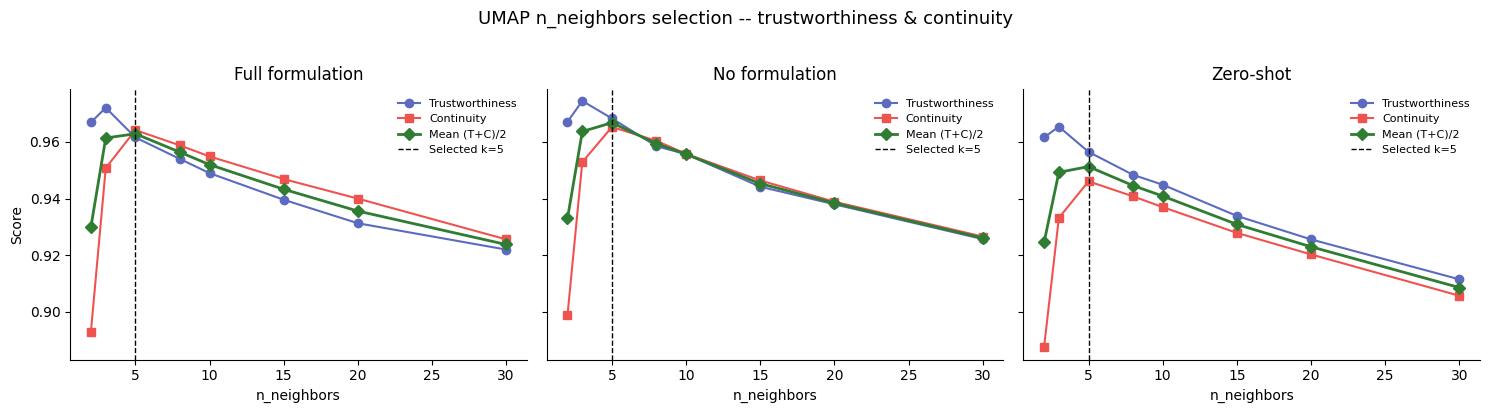

Saved -> ..\data\analysis\umap_neighbor_selection.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, cond in zip(axes, CONDITION_LABELS):
    info   = neighbor_info[cond]
    ks     = sorted(int(k) for k in info["scores"])
    t_vals = [info["scores"][str(k)]["trustworthiness"] for k in ks]
    c_vals = [info["scores"][str(k)]["continuity"]      for k in ks]
    m_vals = [info["scores"][str(k)]["combined"]         for k in ks]
    ax.plot(ks, t_vals, "o-", label="Trustworthiness", color="#5C6BC0")
    ax.plot(ks, c_vals, "s-", label="Continuity",      color="#EF5350")
    ax.plot(ks, m_vals, "D-", label="Mean (T+C)/2",    color="#2E7D32", linewidth=2)
    ax.axvline(info["best_n"], color="black", linestyle="--", linewidth=1,
               label=f"Selected k={info['best_n']}")
    ax.set_title(CONDITION_LABELS[cond], fontsize=12)
    ax.set_xlabel("n_neighbors", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("Score", fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("UMAP n_neighbors selection -- trustworthiness & continuity",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_neighbor_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR / 'umap_neighbor_selection.png'}")


## 4. Compute UMAP projections (cached)

In [6]:
UMAP_CACHE = ANALYSIS_DIR / "umap_coords_per_condition.npz"

if UMAP_CACHE.exists():
    cache = np.load(UMAP_CACHE)
    umap_coords = {k: cache[k] for k in cache.files}
    print("Loaded cached UMAP coords:", {k: v.shape for k, v in umap_coords.items()})
else:
    umap_coords = {}
    for cond in CONDITION_LABELS:
        idx    = df[df["condition"] == cond].index.tolist()
        embs   = embeddings[idx]
        best_n = neighbor_info[cond]["best_n"]
        print(f"{CONDITION_LABELS[cond]}: n_neighbors={best_n}, {len(idx)} vignettes...")
        coords = umap.UMAP(n_components=2, n_neighbors=best_n,
                           min_dist=0.1, random_state=42).fit_transform(embs)
        umap_coords[cond] = coords
        print(f"  done {coords.shape}")
    np.savez(UMAP_CACHE, **umap_coords)
    print(f"Saved -> {UMAP_CACHE}")


Full formulation: n_neighbors=5, 4998 vignettes...


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  done (4998, 2)
No formulation: n_neighbors=5, 4999 vignettes...


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  done (4999, 2)
Zero-shot: n_neighbors=5, 4984 vignettes...


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  done (4984, 2)
Saved -> ..\data\analysis\umap_coords_per_condition.npz


## 5. UMAP plots
### 5a. Colored by model

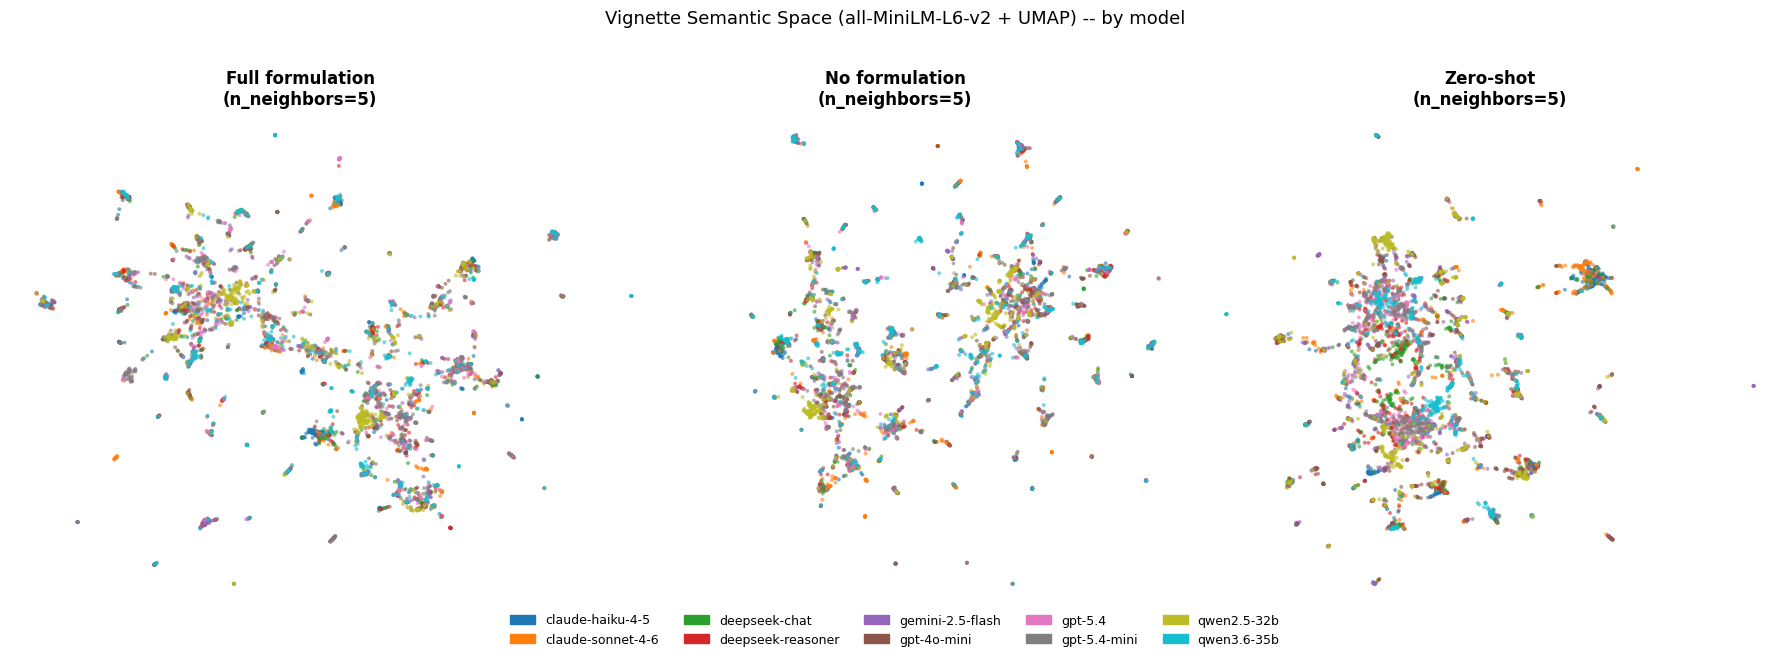

In [13]:
models = sorted(df["model"].unique())
model_color = dict(zip(models, sns.color_palette("tab10", n_colors=len(models))))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cond in zip(axes, CONDITION_LABELS):
    idx     = df[df["condition"] == cond].index
    cond_df = df.loc[idx].reset_index(drop=True)
    coords  = umap_coords[cond]
    best_n  = neighbor_info[cond]["best_n"]
    for model in models:
        mask = (cond_df["model"] == model).values
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[model_color[model]], s=8, alpha=0.6, edgecolors="none")
    ax.set_title(f"{CONDITION_LABELS[cond]}\n(n_neighbors={best_n})",
                 fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
handles = [mpatches.Patch(color=model_color[m], label=m) for m in models]
fig.legend(handles=handles, loc="lower center", ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.06), frameon=False)
plt.suptitle("Vignette Semantic Space (all-MiniLM-L6-v2 + UMAP) -- by model",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_by_condition_model.png", dpi=150, bbox_inches="tight")
plt.show()


### 5c. Grid: one row per model, one column per condition
Gray points = all other models in that condition's UMAP space.
Colored points = this model's vignettes (color = condition).

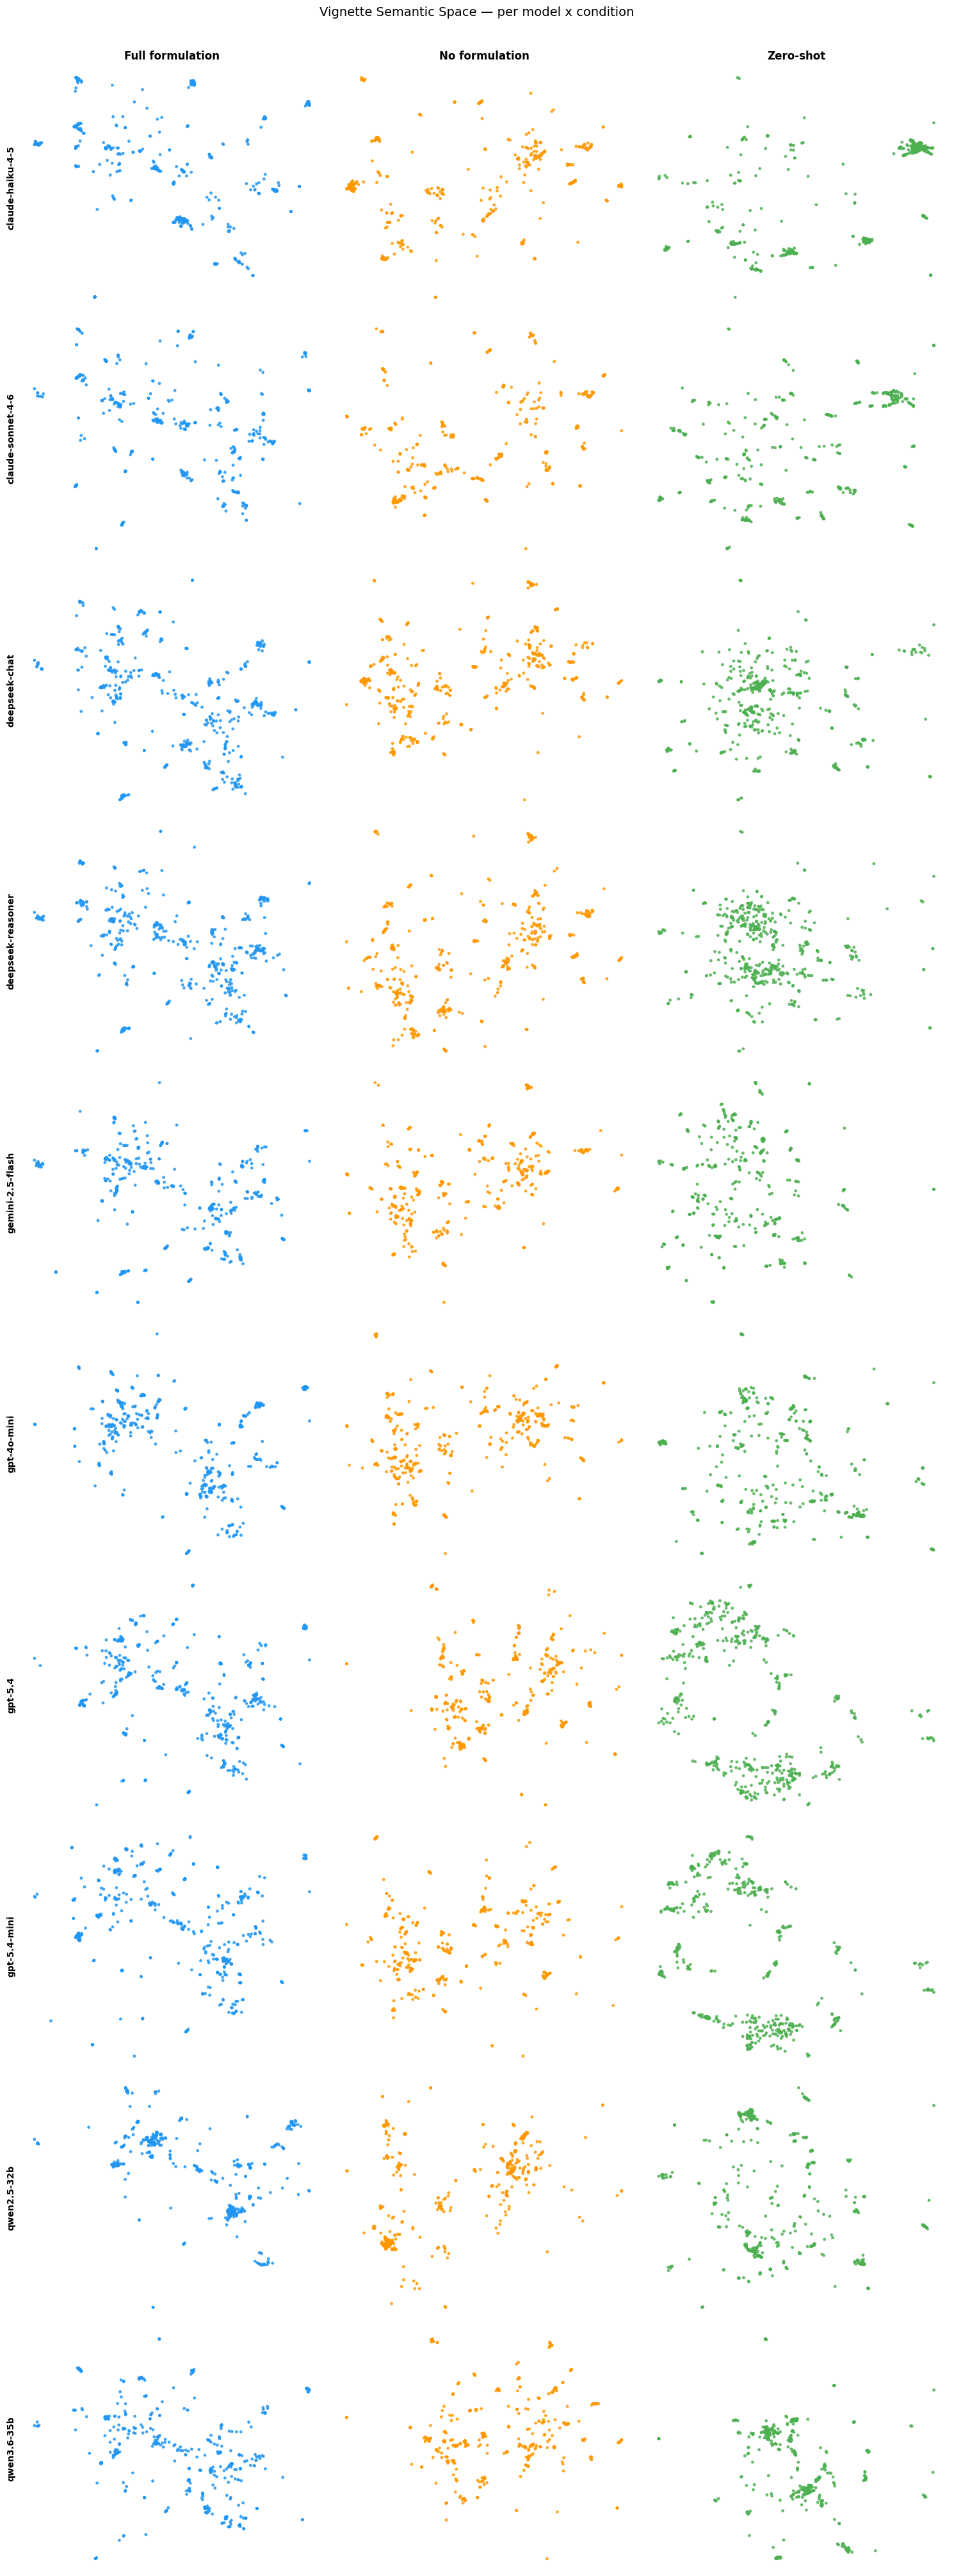

Saved -> ..\data\analysis\umap_per_model_grid.png


In [14]:
models = sorted(df["model"].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))

for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]

        idx        = df[df["condition"] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = umap_coords[cond]
        model_mask = (cond_df["model"] == model).values

        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors="none")

        ax.set_xticks([]); ax.set_yticks([])
        ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight="bold", pad=8)
        if c == 0:
            ax.set_ylabel(model, fontsize=10, fontweight="bold", labelpad=6)

plt.suptitle("Vignette Semantic Space — per model x condition",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_per_model_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR / 'umap_per_model_grid.png'}")


### 5b. Colored by persona

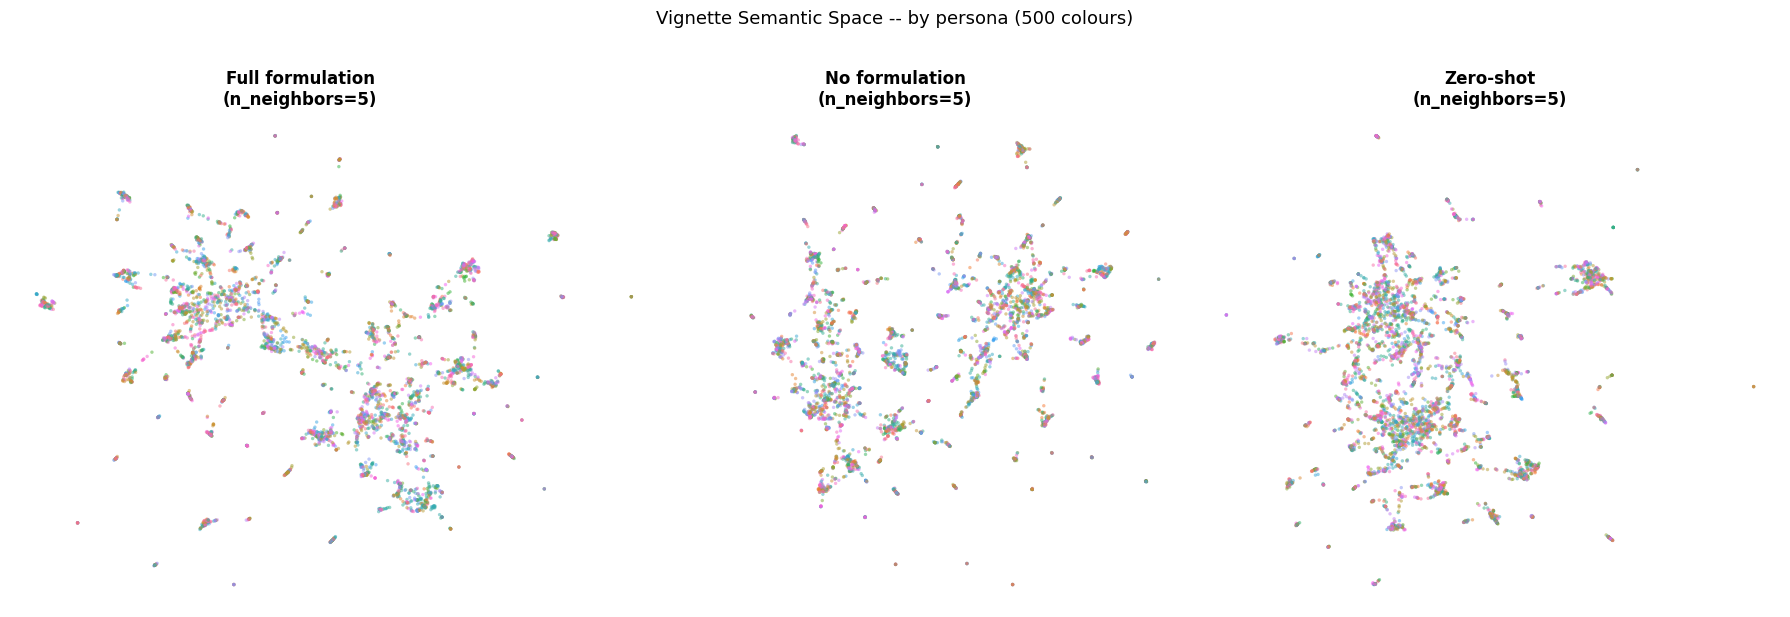

In [15]:
persona_ids   = sorted(df["persona_id"].unique())
persona_color = dict(zip(persona_ids,
                         sns.color_palette("husl", n_colors=len(persona_ids))))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cond in zip(axes, CONDITION_LABELS):
    idx     = df[df["condition"] == cond].index
    cond_df = df.loc[idx].reset_index(drop=True)
    coords  = umap_coords[cond]
    best_n  = neighbor_info[cond]["best_n"]
    ax.scatter(coords[:, 0], coords[:, 1],
               c=[persona_color[p] for p in cond_df["persona_id"]],
               s=6, alpha=0.5, edgecolors="none")
    ax.set_title(f"{CONDITION_LABELS[cond]}\n(n_neighbors={best_n})",
                 fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.suptitle("Vignette Semantic Space -- by persona (500 colours)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_by_condition_persona.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Semantic diversity metrics
### 6a. Mean pairwise cosine distance per condition
Computed in the **original embedding space** (independent of UMAP parameters).
Higher = vignettes more semantically diverse.

In [18]:
diversity_rows = []
for cond in CONDITION_LABELS:
    idx  = df[df["condition"] == cond].index
    embs = embeddings[idx]
    print(f"{CONDITION_LABELS[cond]}: {len(idx)}x{len(idx)} distance matrix...")
    dists = pairwise_distances(embs, metric="cosine")
    upper = dists[np.triu_indices_from(dists, k=1)]
    diversity_rows.append({
        "condition":            cond,
        "label":                CONDITION_LABELS[cond],
        "n":                    len(idx),
        "mean_pairwise_dist":   round(float(upper.mean()), 4),
        "std_pairwise_dist":    round(float(upper.std()),  4),
        "median_pairwise_dist": round(float(np.median(upper)), 4),
    })
    print(f"  mean={upper.mean():.4f}  sd={upper.std():.4f}")

diversity_df = pd.DataFrame(diversity_rows)
diversity_df[["label", "n", "mean_pairwise_dist", "std_pairwise_dist"]]


Full formulation: 4998x4998 distance matrix...
  mean=0.5802  sd=0.0930
No formulation: 4999x4999 distance matrix...
  mean=0.5972  sd=0.0929
Zero-shot: 4984x4984 distance matrix...
  mean=0.6036  sd=0.1017


,label,n,mean_pairwise_dist,std_pairwise_dist
0,Full formulation,4998,0.5802,0.0930
1,No formulation,4999,0.5972,0.0929
2,Zero-shot,4984,0.6036,0.1017


### 6b. Silhouette scores
- **S_model**: do models produce distinct vignettes within a condition?
- **S_persona**: does persona drive semantic content?

Near +1 -> label predicts clusters. Near 0 -> interleaved.

In [19]:
sil_rows = []
for cond in CONDITION_LABELS:
    idx      = df[df["condition"] == cond].index
    embs     = embeddings[idx]
    labels_m = LabelEncoder().fit_transform(df.loc[idx, "model"])
    labels_p = LabelEncoder().fit_transform(df.loc[idx, "persona_id"])
    s_m = silhouette_score(embs, labels_m, metric="cosine")
    s_p = silhouette_score(embs, labels_p, metric="cosine")
    sil_rows.append({"condition": cond, "label": CONDITION_LABELS[cond],
                     "silhouette_by_model": round(s_m, 4),
                     "silhouette_by_persona": round(s_p, 4)})
    print(f"{CONDITION_LABELS[cond]:<22}  S_model={s_m:.4f}  S_persona={s_p:.4f}")

sil_df = pd.DataFrame(sil_rows)


Full formulation        S_model=-0.0062  S_persona=0.0117
No formulation          S_model=-0.0017  S_persona=-0.0059
Zero-shot               S_model=0.0018  S_persona=-0.0118


### 6c. Summary table + save

In [20]:
summary = diversity_df.merge(sil_df, on=["condition", "label"])
summary = summary[["label", "n", "mean_pairwise_dist", "std_pairwise_dist",
                    "silhouette_by_model", "silhouette_by_persona"]]
summary.columns = ["Condition", "N", "Mean pairwise dist", "SD",
                   "Silhouette (model)", "Silhouette (persona)"]
summary = summary.set_index("Condition")
summary.to_csv(ANALYSIS_DIR / "diversity_summary.csv")
print(f"Saved -> {ANALYSIS_DIR / 'diversity_summary.csv'}")
summary.round(4)


Saved -> ..\data\analysis\diversity_summary.csv


,N,Mean pairwise dist,SD,Silhouette (model),Silhouette (persona)
Condition,,,,,
Full formulation,4998,0.5802,0.0930,-0.0062,0.0117
No formulation,4999,0.5972,0.0929,-0.0017,-0.0059
Zero-shot,4984,0.6036,0.1017,0.0018,-0.0118


### 6d. Bar charts

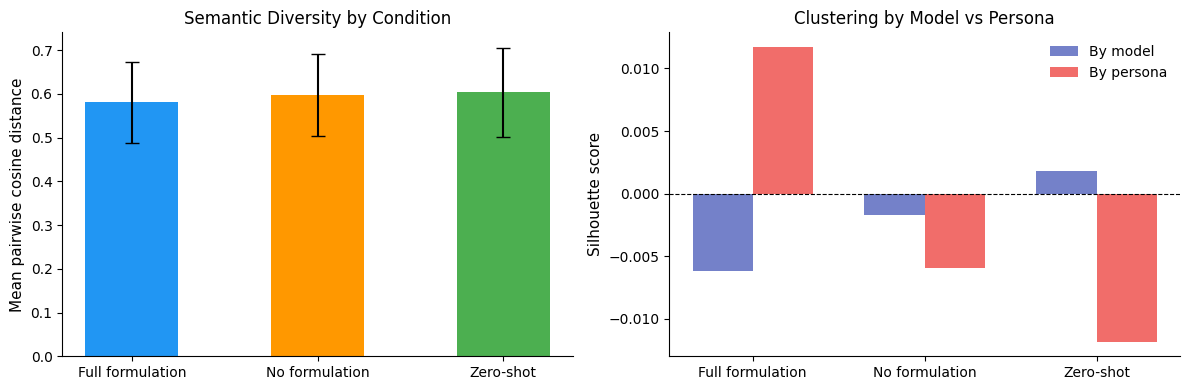

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
di = diversity_df.set_index("condition")
ax.bar(
    [CONDITION_LABELS[c] for c in CONDITION_LABELS],
    [di.loc[c, "mean_pairwise_dist"] for c in CONDITION_LABELS],
    yerr=[di.loc[c, "std_pairwise_dist"] for c in CONDITION_LABELS],
    color=[CONDITION_COLORS[c] for c in CONDITION_LABELS],
    capsize=5, width=0.5, error_kw={"elinewidth": 1.5}
)
ax.set_ylabel("Mean pairwise cosine distance", fontsize=11)
ax.set_title("Semantic Diversity by Condition", fontsize=12)
ax.set_ylim(0, None)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
x = np.arange(len(CONDITION_LABELS))
w = 0.35
si = sil_df.set_index("condition")
ax.bar(x - w/2, [si.loc[c, "silhouette_by_model"]   for c in CONDITION_LABELS],
       width=w, label="By model",   color="#5C6BC0", alpha=0.85)
ax.bar(x + w/2, [si.loc[c, "silhouette_by_persona"] for c in CONDITION_LABELS],
       width=w, label="By persona", color="#EF5350", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_LABELS])
ax.set_ylabel("Silhouette score", fontsize=11)
ax.set_title("Clustering by Model vs Persona", fontsize=12)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "diversity_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


### 6e. Per-model within-condition diversity

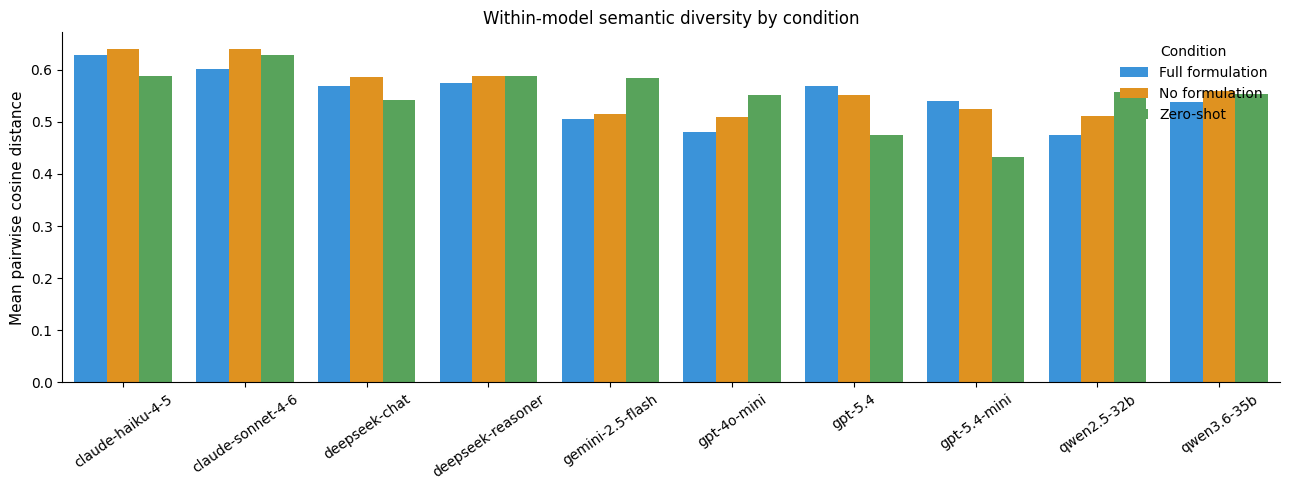

Saved -> ..\data\analysis\diversity_per_model.png


In [22]:
pm_rows = []
for cond in CONDITION_LABELS:
    for model in sorted(df["model"].unique()):
        idx  = df[(df["condition"] == cond) & (df["model"] == model)].index
        if len(idx) < 2:
            continue
        dists = pairwise_distances(embeddings[idx], metric="cosine")
        upper = dists[np.triu_indices_from(dists, k=1)]
        pm_rows.append({"condition": cond, "label": CONDITION_LABELS[cond],
                         "model": model, "mean_dist": upper.mean(), "n": len(idx)})

pm_df = pd.DataFrame(pm_rows)
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=pm_df, x="model", y="mean_dist", hue="label",
            palette=[CONDITION_COLORS[c] for c in CONDITION_LABELS], ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Mean pairwise cosine distance", fontsize=11)
ax.set_title("Within-model semantic diversity by condition", fontsize=12)
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Condition", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "diversity_per_model.png", dpi=150, bbox_inches="tight")
plt.show()
pm_df.to_csv(ANALYSIS_DIR / "diversity_per_model.csv", index=False)
print(f"Saved -> {ANALYSIS_DIR / 'diversity_per_model.png'}")


### 6f. Per-model diversity — pivot table & heatmap

In [23]:
# Pivot table: model x condition
pivot = pm_df.pivot(index="model", columns="label", values="mean_dist")
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]  # fix column order
pivot["mean_across_conditions"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean_across_conditions", ascending=False)
pivot.to_csv(ANALYSIS_DIR / "diversity_per_model_pivot.csv")
pivot.round(4)


label,Full formulation,No formulation,Zero-shot,mean_across_conditions
model,,,,
claude-sonnet-4-6,0.6004,0.6390,0.6270,0.6221
claude-haiku-4-5,0.6274,0.6395,0.5877,0.6182
deepseek-reasoner,0.5735,0.5868,0.5881,0.5828
deepseek-chat,0.5694,0.5849,0.5416,0.5653
qwen3.6-35b,0.5377,0.5597,0.5534,0.5503
gemini-2.5-flash,0.5049,0.5153,0.5844,0.5349
gpt-5.4,0.5683,0.5504,0.4741,0.5309
qwen2.5-32b,0.4746,0.5107,0.5571,0.5141
gpt-4o-mini,0.4809,0.5087,0.5512,0.5136


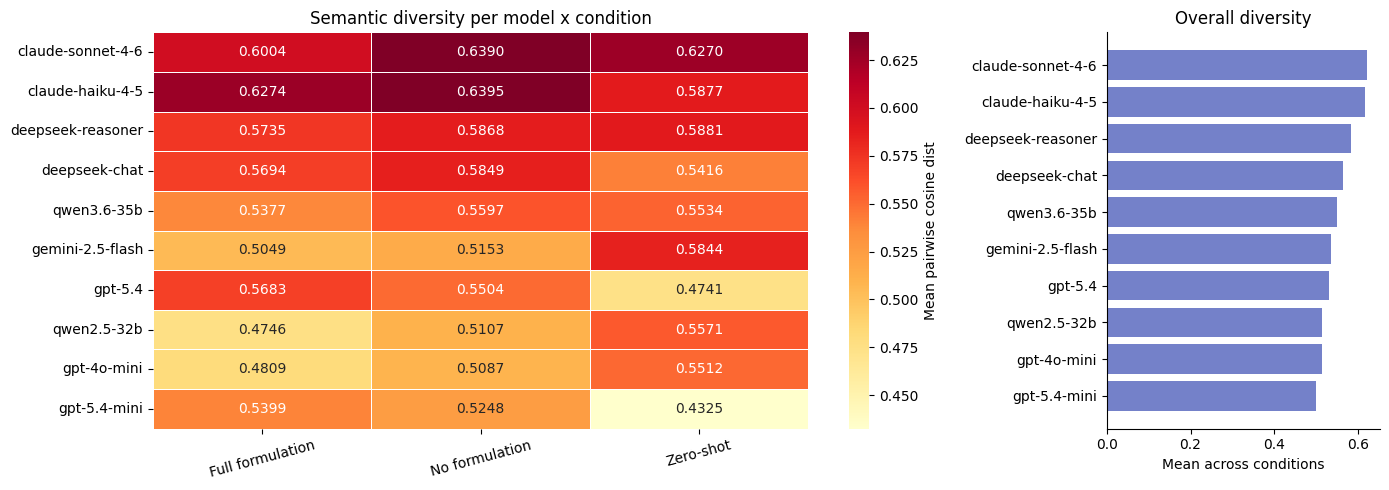

Saved -> ..\data\analysis\diversity_per_model_heatmap.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})

# Heatmap: model x condition
data = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=axes[0], annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Mean pairwise cosine dist"})
axes[0].set_title("Semantic diversity per model x condition", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].tick_params(axis="x", rotation=15)

# Bar: mean across conditions per model
axes[1].barh(pivot.index, pivot["mean_across_conditions"],
             color="#5C6BC0", alpha=0.85)
axes[1].set_xlabel("Mean across conditions", fontsize=10)
axes[1].set_title("Overall diversity", fontsize=12)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "diversity_per_model_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR / 'diversity_per_model_heatmap.png'}")


## 7. Inter-model agreement per persona
For each persona × condition, compute the mean pairwise cosine distance
**across all models** that generated a vignette for that persona.

- **Low distance** → models agree on content → the formulation is driving the text
- **High distance** → models diverge → each model invents its own narrative

If the E&C formulation works as intended, full formulation should show the
**lowest** inter-model distance (highest agreement) across personas.

In [25]:
# For each persona x condition: compute mean pairwise cosine distance
# across all models that have a vignette for that persona.
# Low distance = models agree on content -> formulation is driving the text.
# High distance = models diverge -> each model invents its own narrative.

from sklearn.metrics import pairwise_distances

agreement_rows = []

personas = sorted(df["persona_id"].dropna().unique())

for cond in CONDITION_LABELS:
    cond_df = df[df["condition"] == cond]
    for pid in personas:
        sub = cond_df[cond_df["persona_id"] == pid]
        if len(sub) < 2:
            continue
        embs  = embeddings[sub.index]
        dists = pairwise_distances(embs, metric="cosine")
        upper = dists[np.triu_indices_from(dists, k=1)]
        agreement_rows.append({
            "condition":    cond,
            "label":        CONDITION_LABELS[cond],
            "persona_id":   pid,
            "n_models":     len(sub),
            "mean_dist":    upper.mean(),   # low = models agree
            "std_dist":     upper.std(),
        })

agree_df = pd.DataFrame(agreement_rows)
agree_df.to_csv(ANALYSIS_DIR / "inter_model_agreement.csv", index=False)

# Summary per condition
summary = agree_df.groupby("label")["mean_dist"].agg(["mean","std","median"])
summary.columns = ["mean", "std", "median"]
print("Inter-model distance per condition (lower = more agreement):")
print(summary.round(4))


Inter-model distance per condition (lower = more agreement):
                    mean     std  median
label                                   
Full formulation  0.4099  0.0400  0.4118
No formulation    0.4317  0.0409  0.4341
Zero-shot         0.4408  0.0385  0.4405


C:\Users\amit\AppData\Local\Temp\ipykernel_11232\3595697488.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=12)


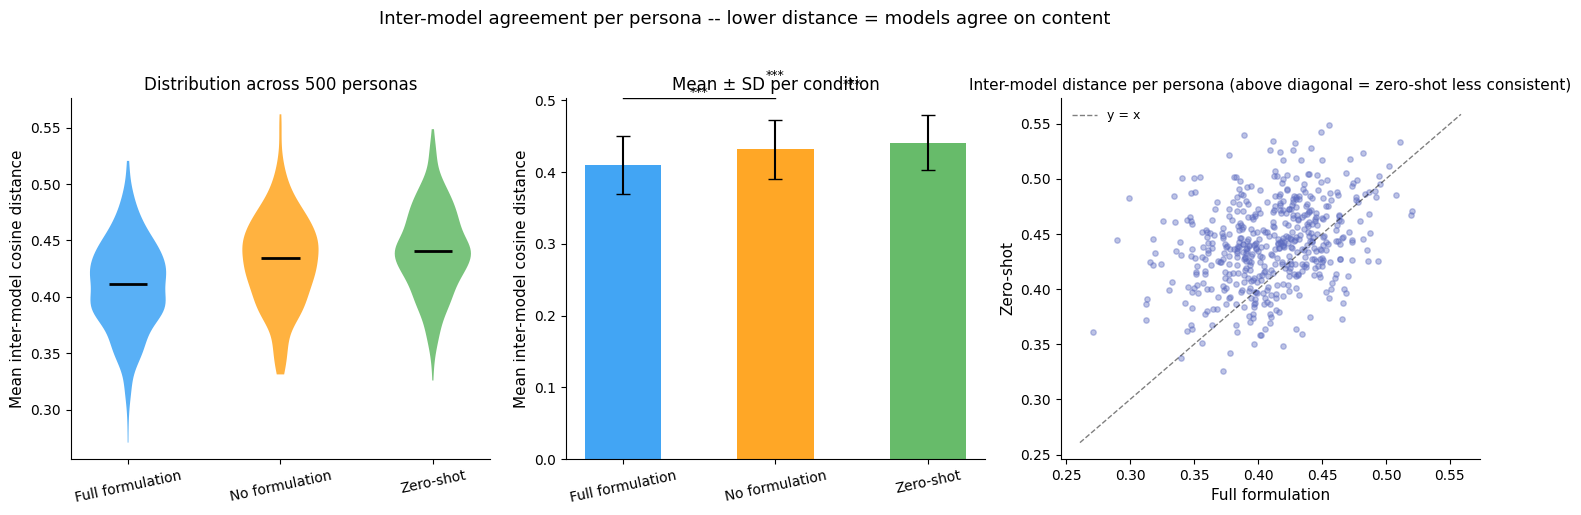

Saved -> ..\data\analysis\inter_model_agreement.png


In [28]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── 1. Violin plot ────────────────────────────────────────────────────────────
ax = axes[0]
order = list(CONDITION_LABELS.values())
data_by_cond = [agree_df[agree_df["label"] == lbl]["mean_dist"].values
                for lbl in order]

parts = ax.violinplot(data_by_cond, positions=range(len(order)),
                      showmedians=True, showextrema=False)
for i, (pc, lbl) in enumerate(zip(parts["bodies"], order)):
    cond_key = [k for k, v in CONDITION_LABELS.items() if v == lbl][0]
    pc.set_facecolor(CONDITION_COLORS[cond_key])
    pc.set_alpha(0.75)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=12)
ax.set_ylabel("Mean inter-model cosine distance", fontsize=11)
ax.set_title("Distribution across 500 personas", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)

# ── 2. Bar chart of means ─────────────────────────────────────────────────────
ax = axes[1]
means = [agree_df[agree_df["label"] == lbl]["mean_dist"].mean() for lbl in order]
stds  = [agree_df[agree_df["label"] == lbl]["mean_dist"].std()  for lbl in order]
colors = [CONDITION_COLORS[[k for k,v in CONDITION_LABELS.items() if v==lbl][0]]
          for lbl in order]
ax.bar(order, means, yerr=stds, color=colors, capsize=5,
       width=0.5, error_kw={"elinewidth": 1.5}, alpha=0.85)
ax.set_ylabel("Mean inter-model cosine distance", fontsize=11)
ax.set_title("Mean ± SD per condition", fontsize=12)
ax.set_xticklabels(order, rotation=12)
ax.set_ylim(0, None)
ax.spines[["top", "right"]].set_visible(False)

# Add significance brackets (t-tests)
pairs = [("Full formulation", "No formulation"),
         ("No formulation",   "Zero-shot"),
         ("Full formulation", "Zero-shot")]
y_max = max(m + s for m, s in zip(means, stds)) * 1.05
for i, (a, b) in enumerate(pairs):
    da = agree_df[agree_df["label"] == a]["mean_dist"]
    db = agree_df[agree_df["label"] == b]["mean_dist"]
    t, p = stats.ttest_ind(da, db)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    xa, xb = order.index(a), order.index(b)
    y = y_max + i * 0.012
    ax.plot([xa, xb], [y, y], color="black", linewidth=1)
    ax.text((xa + xb) / 2, y + 0.002, sig, ha="center", fontsize=9)

# ── 3. Per-persona scatter: full vs zero-shot ─────────────────────────────────
ax = axes[2]
full = agree_df[agree_df["condition"] == "full"].set_index("persona_id")["mean_dist"]
zero = agree_df[agree_df["condition"] == "zero_shot"].set_index("persona_id")["mean_dist"]
common = full.index.intersection(zero.index)
ax.scatter(full[common], zero[common], alpha=0.4, s=15, color="#5C6BC0")
lims = [min(full[common].min(), zero[common].min()) - 0.01,
        max(full[common].max(), zero[common].max()) + 0.01]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="y = x")
ax.set_xlabel("Full formulation", fontsize=11)
ax.set_ylabel("Zero-shot", fontsize=11)
ax.set_title("Inter-model distance per persona (above diagonal = zero-shot less consistent)", fontsize=11)
ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Inter-model agreement per persona -- lower distance = models agree on content",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "inter_model_agreement.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR / 'inter_model_agreement.png'}")


## 8. DSM-5 / E&C component cosine-similarity coverage
For each vignette we compute the **dot product** (= cosine similarity for L2-normalised
vectors) against 9 short clinical query strings: 4 DSM-5 symptom clusters and 5 Ehlers &
Clark (2000) components. A vignette *covers* a dimension when its similarity exceeds a
threshold (default 0.25).

Key question: does adding clinical structure (full formulation) increase coverage of
relevant clinical content compared with zero-shot?


In [29]:
from sentence_transformers import SentenceTransformer

QUERIES = {
    # DSM-5 symptom clusters
    "DSM-5: Re-experiencing":        "intrusive memories, flashbacks, nightmares about the trauma",
    "DSM-5: Avoidance":              "avoiding trauma reminders, places, people, thoughts and feelings",
    "DSM-5: Neg. cognitions & mood": "guilt, shame, distorted beliefs, emotional numbing, estrangement",
    "DSM-5: Hyperarousal":           "hypervigilance, sleep problems, irritability, exaggerated startle",
    # E&C (2000) components
    "E&C: Trauma memory":            "fragmented trauma memory, gaps, poor contextualisation, sensory intrusions",
    "E&C: Negative appraisals":      "catastrophic personal meaning, self-blame, permanent change",
    "E&C: Triggers":                 "situational and internal cues that activate trauma memory",
    "E&C: Current threat":           "sense of ongoing danger, mental defeat, threat not yet in the past",
    "E&C: Maladaptive coping":       "thought suppression, rumination, substance use, safety behaviours",
}

_enc = SentenceTransformer('all-MiniLM-L6-v2')
query_embs = _enc.encode(
    list(QUERIES.values()),
    normalize_embeddings=True,
    show_progress_bar=False,
)  # shape: (9, 384)

query_labels = list(QUERIES.keys())
print(f"Query embeddings: {query_embs.shape}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query embeddings: (9, 384)


In [30]:
# dot product == cosine similarity (embeddings already L2-normalised)
sims = embeddings @ query_embs.T   # (n_vignettes, 9)
print(f"Similarity matrix: {sims.shape}  min={sims.min():.3f}  max={sims.max():.3f}")

sim_df = df[['persona_id', 'model', 'condition']].copy()
for i, lbl in enumerate(query_labels):
    sim_df[lbl] = sims[:, i]

THRESHOLD = 0.25
print(f"\nCoverage rate (sim > {THRESHOLD}) per condition:")
for cond, lbl in CONDITION_LABELS.items():
    sub = sim_df[sim_df['condition'] == cond]
    rates = {q: (sub[q] > THRESHOLD).mean() for q in query_labels}
    avg   = sum(rates.values()) / len(rates)
    print(f"  {lbl:<22}  avg_coverage={avg:.3f}")


Similarity matrix: (14981, 9)  min=-0.063  max=0.691

Coverage rate (sim > 0.25) per condition:
  Full formulation        avg_coverage=0.748
  No formulation          avg_coverage=0.662
  Zero-shot               avg_coverage=0.563


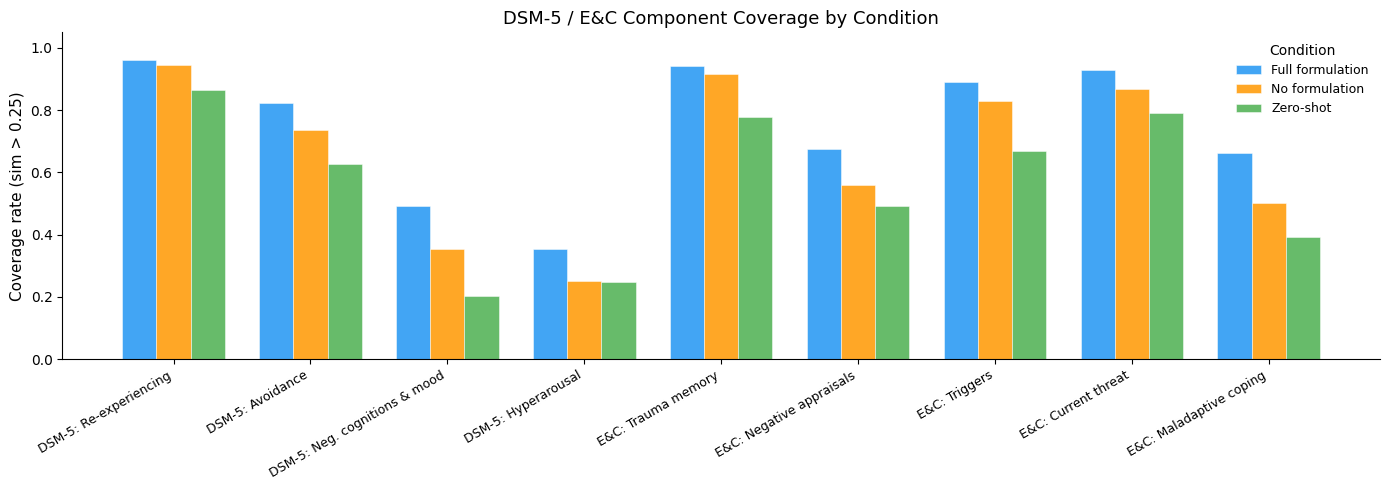

Saved -> ..\data\analysis/dsm5_ec_coverage_bar.png


In [31]:
THRESHOLD = 0.25
conds = list(CONDITION_LABELS.keys())
cov_matrix = np.zeros((len(conds), len(query_labels)))
for ci, cond in enumerate(conds):
    sub = sim_df[sim_df['condition'] == cond]
    for qi, q in enumerate(query_labels):
        cov_matrix[ci, qi] = (sub[q] > THRESHOLD).mean()

x = np.arange(len(query_labels))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 5))
for ci, cond in enumerate(conds):
    ax.bar(x + ci * width, cov_matrix[ci], width=width,
           label=CONDITION_LABELS[cond], color=CONDITION_COLORS[cond],
           alpha=0.85, edgecolor='white', linewidth=0.4)
ax.set_xticks(x + width)
ax.set_xticklabels(query_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel(f'Coverage rate (sim > {THRESHOLD})', fontsize=11)
ax.set_title('DSM-5 / E&C Component Coverage by Condition', fontsize=13)
ax.legend(title='Condition', frameon=False, fontsize=9)
ax.set_ylim(0, 1.05)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'dsm5_ec_coverage_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS_DIR}/dsm5_ec_coverage_bar.png')


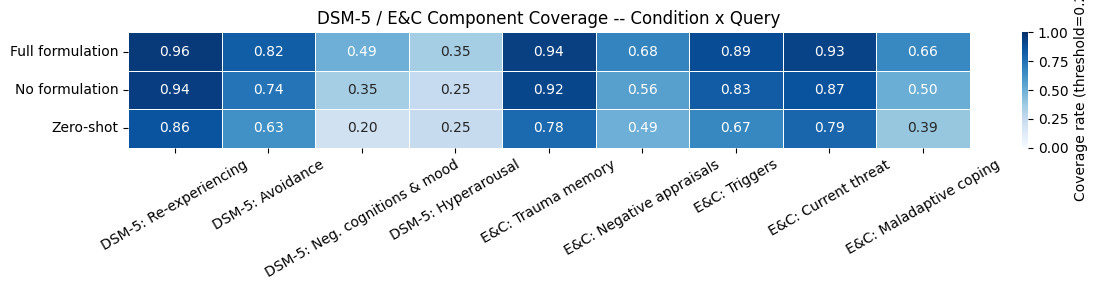

Saved -> ..\data\analysis/dsm5_ec_coverage_heatmap.png


In [32]:
cov_df = pd.DataFrame(
    cov_matrix,
    index=[CONDITION_LABELS[c] for c in conds],
    columns=query_labels,
)

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    cov_df, ax=ax, annot=True, fmt='.2f', cmap='Blues',
    vmin=0, vmax=1, linewidths=0.5,
    cbar_kws={'label': f'Coverage rate (threshold={THRESHOLD})'},
)
ax.set_title('DSM-5 / E&C Component Coverage -- Condition x Query', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'dsm5_ec_coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
cov_df.round(3).to_csv(ANALYSIS_DIR / 'dsm5_ec_coverage.csv')
print(f'Saved -> {ANALYSIS_DIR}/dsm5_ec_coverage_heatmap.png')


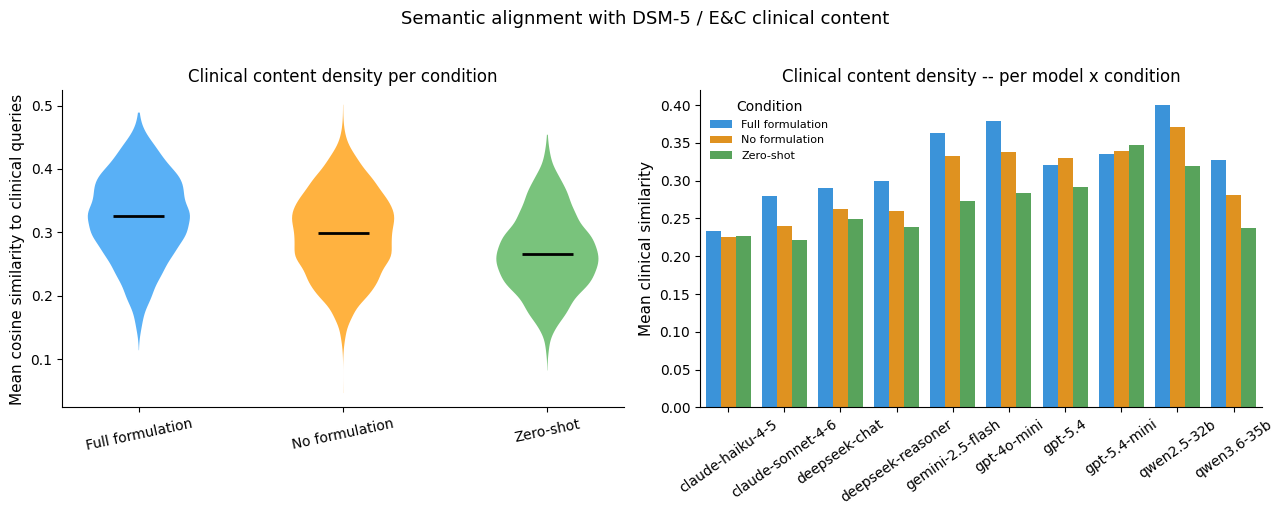

Saved -> ..\data\analysis/clinical_content_density.png


In [33]:
sim_df['mean_clinical_sim'] = sim_df[query_labels].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin of mean clinical similarity
ax = axes[0]
order = list(CONDITION_LABELS.values())
data_v = [sim_df[sim_df['condition'] == c]['mean_clinical_sim'].values
          for c in CONDITION_LABELS]
parts = ax.violinplot(data_v, positions=range(len(order)),
                      showmedians=True, showextrema=False)
for pc, cond in zip(parts['bodies'], CONDITION_LABELS):
    pc.set_facecolor(CONDITION_COLORS[cond])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=12)
ax.set_ylabel('Mean cosine similarity to clinical queries', fontsize=11)
ax.set_title('Clinical content density per condition', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

# Per-model mean clinical sim
ax = axes[1]
pm_sim = (sim_df.groupby(['model', 'condition'])['mean_clinical_sim']
          .mean().reset_index())
pm_sim['label'] = pm_sim['condition'].map(CONDITION_LABELS)
sns.barplot(data=pm_sim, x='model', y='mean_clinical_sim', hue='label',
            palette=[CONDITION_COLORS[c] for c in CONDITION_LABELS], ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Mean clinical similarity', fontsize=11)
ax.set_title('Clinical content density -- per model x condition', fontsize=12)
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Condition', frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Semantic alignment with DSM-5 / E&C clinical content', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'clinical_content_density.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS_DIR}/clinical_content_density.png')
